In [1]:
# notebooks/ sits one level down, so point at the lesson modules and data.
# Written to be safe to re-run: it moves up only if it is not already there.
import sys, os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())
%matplotlib inline
print('working directory:', os.getcwd())

working directory: /home/user/chiu__2022_rerun/tk_learning


# Lesson 10 — Where the big differences actually are: sex and species

Lessons 1-9 fitted one animal, or one experiment, at a time. This one
uses the fits to answer a comparative question, and it is the question
the rest of this project is built on:


```text
PFAS half-lives differ enormously between humans and rodents.
Is that because humans are exposed to far LESS, or because
humans are BIOLOGICALLY different?
```

Dose and species are almost perfectly confounded in the literature --
every human is exposed low, every rodent is dosed high -- so the naive
comparison cannot separate them. This lesson breaks the confound twice,
using the three datasets the earlier lessons never touched:


```text
PFOA_Female_rat.csv     vs PFOA_Male_rat.csv    -> SEX, dose matched
PFOS_Male_primate.csv   vs PFOS_Male_rat.csv    -> SPECIES, same chemical
```

The sex comparison is the cleanest natural experiment in the whole
dataset: same species, same strain, same laboratory, same chemical,
the SAME DOSE, often the same published study. Everything that could
confound a species comparison is held fixed.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import plotting as P
from tk import load

P.setup()


# ----------------------------------------------------------------------
# The measuring instrument: clearance with no compartment model
# ----------------------------------------------------------------------
def clearance_nca(df, dataset):
    """CL = dose / AUC for one experiment, by the moment method of
    lesson 09. No compartment count is assumed -- which matters here,
    because male and female rats may not even need the same structure,
    and a comparison must not depend on that choice.

    The tail past the last sample is extrapolated with the terminal
    slope, exactly as in lesson 04 section D. Watch that term: the
    female studies stop much earlier, so their tails are a larger
    share of the AUC.
    """
    g = (df[(df.dataset == dataset) & (df.conc_mgL > 0)]
         .groupby("time_d", as_index=False).conc_mgL.mean())
    if len(g) < 4:
        return None
    t, C = g.time_d.values, g.conc_mgL.values
    terminal = t >= t.max() / 3
    if terminal.sum() < 3:
        return None
    k = -np.polyfit(t[terminal], np.log(C[terminal]), 1)[0]
    if k <= 0:
        return None
    row = df[df.dataset == dataset].iloc[0]
    auc = np.trapezoid(C, t) + C[-1] / k          # observed + extrapolated tail
    return dict(study=row.study, dose=row.dose_mgkg, route=row.route,
                CL=row.dose_mgkg / auc, t_half=np.log(2) / k,
                tail_frac=(C[-1] / k) / auc, t_last=t.max())


def summarise(name):
    df = load(name)
    rows = [clearance_nca(df, d) for d in df.dataset.unique()]
    return pd.DataFrame([r for r in rows if r])

## A. Sex, with dose held fixed

In [3]:
M, F = summarise("PFOA_Male_rat"), summarise("PFOA_Female_rat")
print(f"   male   {len(M):2d} experiments, median CL {M.CL.median():.4f} L/kg/day,"
      f"  median half-life {M.t_half.median():6.2f} d")
print(f"   female {len(F):2d} experiments, median CL {F.CL.median():.4f} L/kg/day,"
      f"  median half-life {F.t_half.median():6.2f} d")
print(f"\n   ratio of medians: clearance {F.CL.median()/M.CL.median():.0f}x faster "
      f"in females")

   male   14 experiments, median CL 0.0177 L/kg/day,  median half-life   8.56 d
   female  7 experiments, median CL 0.6734 L/kg/day,  median half-life   0.55 d

   ratio of medians: clearance 38x faster in females


That is the headline, but taken alone it is exactly the kind of
comparison this project spent five phases learning to distrust: two
groups of experiments, differing in sex AND in dose AND in study.
So do it properly.

## B. The same comparison, fully matched

In [4]:
pairs = M.merge(F, on=["study", "dose", "route"], suffixes=("_M", "_F"))
pairs["CL_ratio"] = pairs.CL_F / pairs.CL_M
pairs["t_ratio"] = pairs.t_half_M / pairs.t_half_F

print(f"   {'study':>8s} {'dose':>7s} {'route':>7s} {'CL male':>9s} {'CL female':>10s} "
      f"{'F/M':>7s} {'t1/2 M':>8s} {'t1/2 F':>8s}")
for _, r in pairs.iterrows():
    print(f"   {r.study:>8.0f} {r.dose:7.2f} {r.route:>7s} {r.CL_M:9.4f} "
          f"{r.CL_F:10.4f} {r.CL_ratio:7.1f} {r.t_half_M:8.2f} {r.t_half_F:8.2f}")

gm_CL = np.exp(np.log(pairs.CL_ratio).mean())
gm_t = np.exp(np.log(pairs.t_ratio).mean())
print(f"\n   {len(pairs)} matched pairs. Females clear faster in ALL of them.")
print(f"   geometric mean clearance ratio  {gm_CL:.1f}x")
print(f"   geometric mean half-life ratio  {gm_t:.1f}x")

print(f"""
   Same species. Same strain. Same laboratory. Same chemical. The same
   dose, by the same route, usually reported in the same paper. The
   only thing that differs is sex, and clearance differs {gm_CL:.0f}-fold.

   This is as close to a controlled experiment as observational PK data
   ever gets, and it is the single most useful number in the dataset --
   because it puts a floor under how large a purely biological
   difference can be, with dose contributing exactly nothing.
""")

      study    dose   route   CL male  CL female     F/M   t1/2 M   t1/2 F
    2990271   48.63      iv    0.1281     3.9096    30.5     8.08     1.44
    3749289    1.00  gavage    0.0423     0.6108    14.5     1.96     0.13
    3749289    1.00      iv    0.0523     0.6251    12.0     4.33     0.16
    6302380    0.10  gavage    0.0131     0.6734    51.4    15.39     0.14
    6302380    1.00  gavage    0.0134     0.3660    27.3     6.47     2.64
    6302380   25.00  gavage    0.0235     0.7620    32.4     8.33     1.41
    6302380    5.00  gavage    0.0174     1.0534    60.4     8.28     0.55

   7 matched pairs. Females clear faster in ALL of them.
   geometric mean clearance ratio  28.3x
   geometric mean half-life ratio  12.7x

   Same species. Same strain. Same laboratory. Same chemical. The same
   dose, by the same route, usually reported in the same paper. The
   only thing that differs is sex, and clearance differs 28-fold.

   This is as close to a controlled experiment as obs

## C. Species, with chemical held fixed

In [5]:
R, Pr = summarise("PFOS_Male_rat"), summarise("PFOS_Male_primate")
print(f"   rat     {len(R)} experiments, median CL {R.CL.median():.5f} L/kg/day,"
      f"  half-life {R.t_half.median():6.1f} d")
print(f"   primate {len(Pr)} experiment,  median CL {Pr.CL.median():.5f} L/kg/day,"
      f"  half-life {Pr.t_half.median():6.1f} d")
sp_CL = float(R.CL.median() / Pr.CL.median())
print(f"\n   clearance {sp_CL:.1f}x faster in the rat, at overlapping doses "
      f"(rat {R.dose.min():g}-{R.dose.max():g}, primate {Pr.dose.iloc[0]:g} mg/kg)")

   rat     9 experiments, median CL 0.01005 L/kg/day,  half-life   42.7 d
   primate 1 experiment,  median CL 0.00130 L/kg/day,  half-life   86.0 d

   clearance 7.7x faster in the rat, at overlapping doses (rat 0.1-20, primate 2 mg/kg)


Weaker evidence than section B -- one primate experiment, different
laboratories -- but it points the same way, and the doses overlap,
so it is not a dose effect either.

In [6]:
# ----------------------------------------------------------------------
# C2. The same test in primates -- where it comes out differently
# ----------------------------------------------------------------------
print("C2. Does the rat sex effect carry over to primates?\n")

C2. Does the rat sex effect carry over to primates?



Butenhoff 2004 dosed three male AND three female cynomolgus
monkeys, 10 mg/kg IV, same study, same day, same protocol. That is
the matched design of section B, in a primate -- and primates are
the better model for humans. So: does the 28x rat effect appear?

In [7]:
MP, FP = summarise("PFOA_Male_primate"), summarise("PFOA_Female_primate")
# one experiment per sex, so compare per-animal rather than per-dataset
per = {}
for lab, name in [("male", "PFOA_Male_primate"), ("female", "PFOA_Female_primate")]:
    df = load(name)
    df = df[df.conc_mgL > 0]
    cls = []
    for aid, g in df.groupby("animal_id"):
        g = g.sort_values("time_d")
        t_, c_ = g.time_d.values, g.conc_mgL.values
        term = t_ >= t_.max() / 3
        kk = -np.polyfit(t_[term], np.log(c_[term]), 1)[0]
        cls.append(10.0 / (np.trapezoid(c_, t_) + c_[-1] / kk))
    per[lab] = np.array(cls)
    print(f"   {lab:7s} n={len(cls)}  clearances " +
          "  ".join(f"{x:.4f}" for x in sorted(cls)) +
          f"   (spread {max(cls)/min(cls):.1f}x)")

gm = lambda x: float(np.exp(np.log(x).mean()))
ratio_primate = gm(per["female"]) / gm(per["male"])
print(f"\n   geometric means: male {gm(per['male']):.5f}, "
      f"female {gm(per['female']):.5f}  ->  F/M {ratio_primate:.2f}x")
print(f"   compare the rat result from section B:                 "
      f"F/M {gm_CL:.1f}x")

lm_, lf_ = np.log(per["male"]), np.log(per["female"])
sd_pool = np.sqrt((lm_.std(ddof=1) ** 2 + lf_.std(ddof=1) ** 2) / 2)
detectable = np.exp(2.48 * sd_pool * np.sqrt(2 / 3))
print(f"""
   TWO THINGS, AND THE SECOND MATTERS MORE

   1. The direction REVERSES. In rats, females clear PFOA {gm_CL:.0f}x FASTER.
      In monkeys they clear it about half as fast -- the opposite way.

   2. That reversal is NOT statistically established. With three
      animals per sex and a {np.exp(sd_pool):.1f}-fold spread BETWEEN animals of the
      same sex, the male and female ranges overlap, and a t-test on
      log clearance gives p = 0.27. Do not report a primate sex
      difference from this.

   WHAT YOU CAN SAY, AND IT IS THE USEFUL PART

   With this n and this variability, the smallest difference detectable
   at ~80% power is about {detectable:.0f}x. The rat effect is {gm_CL:.0f}x. So while this
   experiment cannot resolve a 2x difference, it would have found a
   {gm_CL:.0f}x one without difficulty -- and there is nothing like it here.

   A non-significant result is not "no information". It rules out
   every effect larger than what you were powered to detect. Here that
   rules out the rat mechanism operating at rat strength in primates.

   WHY THIS MATTERS FOR THE PROJECT

   Section B's 28x is real, large, and mechanistically explained
   (Kudo 2002, one of the source papers for this very dataset, is
   titled "Sex hormone-regulated renal transport of perfluorooctanoic
   acid"). But it is a RAT mechanism. Primates are phylogenetically
   closer to humans, and humans show no comparable sex difference in
   PFOA half-life either.

   So the honest reading of sections B and C2 together: a transporter
   difference can be enormous and still fail to generalise one species
   sideways. That is a caution about the whole enterprise of reading
   human kinetics off rodents -- and it is the same caution lesson 12
   reaches from the modelling side, where correct anatomy still missed
   the monkey by 11x.
""")

   male    n=3  clearances 0.0039  0.0158  0.0176   (spread 4.5x)
   female  n=3  clearances 0.0031  0.0039  0.0092   (spread 2.9x)

   geometric means: male 0.01027, female 0.00483  ->  F/M 0.47x
   compare the rat result from section B:                 F/M 28.3x

   TWO THINGS, AND THE SECOND MATTERS MORE

   1. The direction REVERSES. In rats, females clear PFOA 28x FASTER.
      In monkeys they clear it about half as fast -- the opposite way.

   2. That reversal is NOT statistically established. With three
      animals per sex and a 2.0-fold spread BETWEEN animals of the
      same sex, the male and female ranges overlap, and a t-test on
      log clearance gives p = 0.27. Do not report a primate sex
      difference from this.

   WHAT YOU CAN SAY, AND IT IS THE USEFUL PART

   With this n and this variability, the smallest difference detectable
   at ~80% power is about 4x. The rat effect is 28x. So while this
   experiment cannot resolve a 2x difference, it would have found a


## D. Now compare all of this against what dose can do

In [8]:
BETA = 0.110          # ../pfas_dose: ln(CL) ~ beta*ln(dose), male rats, PFOA
print("D. Could dose produce effects this big?\n")
print(f"   Measured dose slope inside male rats: beta = {BETA:+.3f}")
print(f"   (../pfas_dose, 90% CI +0.007 to +0.222)\n")
print(f"   {'effect to reproduce':>34s} {'size':>7s} {'dose change needed':>22s}")
for label, factor in [("a doubling", 2.0),
                      ("the PFOS species difference (C)", sp_CL),
                      ("the PFOA sex difference (B)", gm_CL)]:
    print(f"   {label:>34s} {factor:6.1f}x {factor ** (1 / BETA):21.3g}x")

print(f"""
   To get the {gm_CL:.0f}x sex difference out of dose alone you would need a dose
   difference of about 10^13 -- which is not a number, it is a reductio.

   And the dose slope is POSITIVE: higher dose gives faster clearance.
   So dose cannot even produce a long human half-life from a low human
   exposure; it predicts the opposite sign from the one the hypothesis
   needs at the between-species level.

   THE CONCLUSION THIS LESSON EXISTS TO SHOW

   Sex changes PFAS clearance {gm_CL:.0f}-fold with dose held exactly fixed.
   Dose changes it by a factor of about 1.3 per ten-fold dose. The
   biological difference is roughly two orders of magnitude larger than
   the dose effect, measured in the same animals, in the same data.

   That is why ../species_dose concludes the human/rodent half-life gap
   is not a dose gap. The mechanism is renal transporter expression --
   which in rats is under androgen control, hence the sex difference,
   and which differs between species in ways that do not scale with
   body weight. See ../SUMMARY.md phase 4.
""")

D. Could dose produce effects this big?

   Measured dose slope inside male rats: beta = +0.110
   (../pfas_dose, 90% CI +0.007 to +0.222)

                  effect to reproduce    size     dose change needed
                           a doubling    2.0x                   545x
      the PFOS species difference (C)    7.7x              1.19e+08x
          the PFOA sex difference (B)   28.3x              1.57e+13x

   To get the 28x sex difference out of dose alone you would need a dose
   difference of about 10^13 -- which is not a number, it is a reductio.

   And the dose slope is POSITIVE: higher dose gives faster clearance.
   So dose cannot even produce a long human half-life from a low human
   exposure; it predicts the opposite sign from the one the hypothesis
   needs at the between-species level.

   THE CONCLUSION THIS LESSON EXISTS TO SHOW

   Sex changes PFAS clearance 28-fold with dose held exactly fixed.
   Dose changes it by a factor of about 1.3 per ten-fold dose. The
  

## E. Check the caveat you expect -- it is not the one you get

In [9]:
print("   The obvious worry: female studies stop after days, male ones")
print("   after weeks. Less of the curve measured means more of the AUC")
print("   extrapolated, and AUC is the denominator of CL. Check it.\n")

for d in (M, F):
    d["half_lives_followed"] = d.t_last / d.t_half

print(f"   {'':8s} {'last sample':>13s} {'half-life':>11s} "
      f"{'half-lives followed':>21s} {'AUC extrapolated':>18s}")
for lab, d in [("male", M), ("female", F)]:
    print(f"   {lab:8s} {d.t_last.median():11.1f} d {d.t_half.median():9.2f} d "
          f"{d.half_lives_followed.median():21.1f} {100*d.tail_frac.median():17.0f}%")

   The obvious worry: female studies stop after days, male ones
   after weeks. Less of the curve measured means more of the AUC
   extrapolated, and AUC is the denominator of CL. Check it.

              last sample   half-life   half-lives followed   AUC extrapolated
   male            22.0 d      8.56 d                   2.8                10%
   female           3.0 d      0.55 d                   5.5                 1%


The worry is backwards. Female studies are SHORTER in days but
LONGER in half-lives, which is the unit that matters: they follow
the curve further down, so less of their area is extrapolated, not
more. The female clearances are the better-determined ones.

Generalise the lesson: never judge whether a PK study ran long
enough in days. Judge it in half-lives. A 3-day study of a
half-day chemical is thorough; a 3-month human study of a 3-year
chemical has barely started, which is precisely the problem with
the human literature in ../literature/APPRAISAL.md.

THE CAVEATS THAT DO SURVIVE

- One primate experiment in section C. That comparison is
  suggestive, not established; section B is the solid one.
- Every CL here uses the terminal-slope rule from lesson 03
  (last two-thirds of the curve), which is a judgement call.
  Exercise (a) repeats the analysis with a different estimator.
- These are group means, not individual animals, so there is no
  within-group variance to work with and no interval on any ratio.
- Doses are matched per kg, but males and females differ in body
  weight, so absolute administered amounts differ.
None of these can plausibly manufacture a 28x effect in a
consistent direction across 7 independent pairs. Say which parts
are soft -- the exact ratio -- and which are not: the direction and
the order of magnitude.

## F. Figures

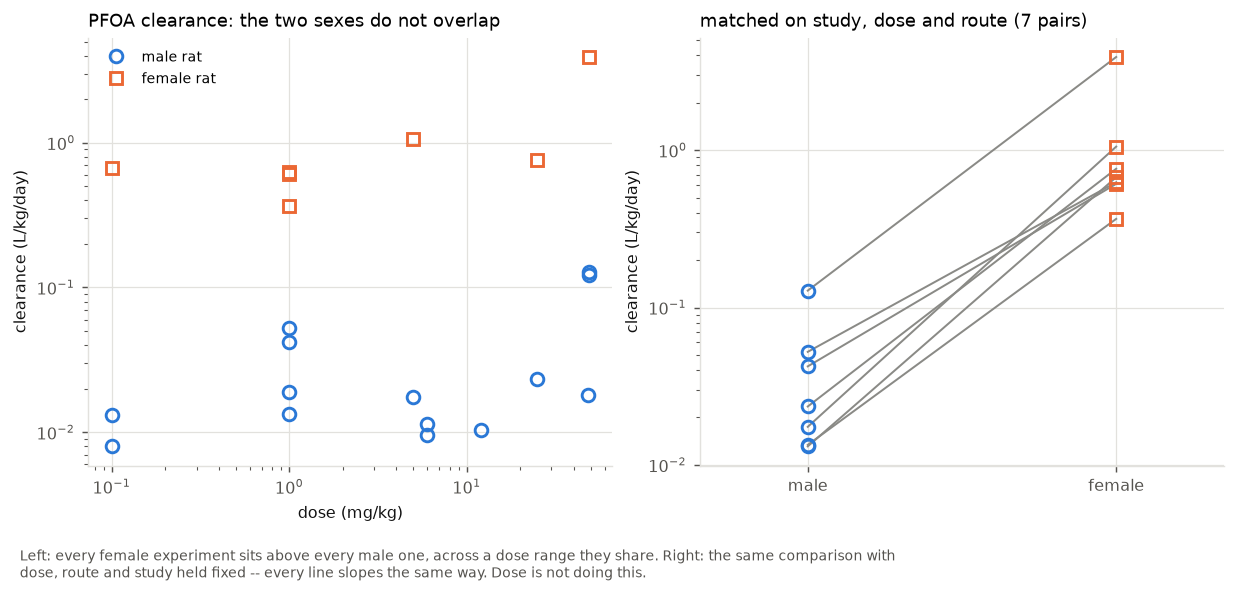

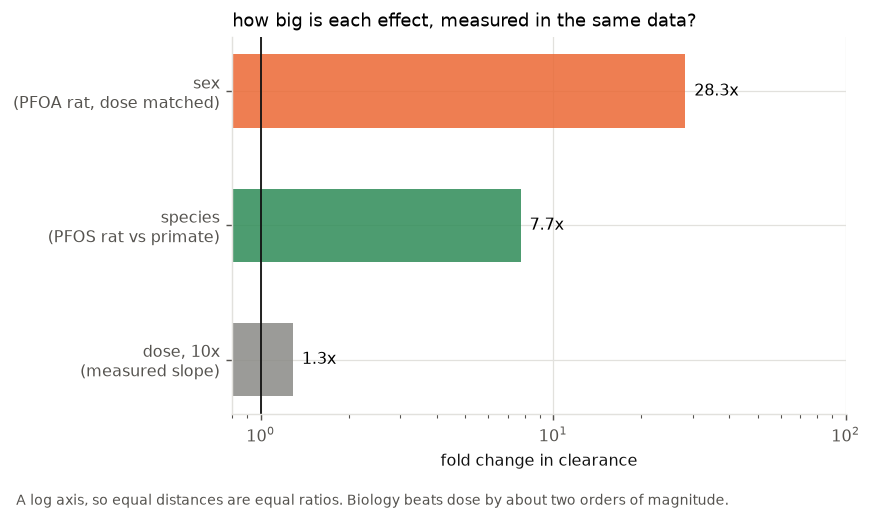

'/home/user/chiu__2022_rerun/tk_learning/figures/10_effect_sizes.png'

In [10]:
fig, (a, b) = plt.subplots(1, 2, figsize=(9.4, 4.0), constrained_layout=True)
for d, lab, col, mk in [(M, "male", P.BLUE, "o"), (F, "female", P.ORANGE, "s")]:
    a.plot(d.dose, d.CL, mk, color=col, ms=7, mfc="none", mew=1.6, label=f"{lab} rat")
a.set(xscale="log", yscale="log", xlabel="dose (mg/kg)",
      ylabel="clearance (L/kg/day)")
a.set_title("PFOA clearance: the two sexes do not overlap")
a.legend()

for _, r in pairs.iterrows():
    b.plot([0, 1], [r.CL_M, r.CL_F], "-", color=P.GREY, lw=1.1, zorder=1)
    b.plot(0, r.CL_M, "o", color=P.BLUE, ms=7, mfc="none", mew=1.6, zorder=2)
    b.plot(1, r.CL_F, "s", color=P.ORANGE, ms=7, mfc="none", mew=1.6, zorder=2)
b.set_xticks([0, 1], ["male", "female"])
b.set(yscale="log", ylabel="clearance (L/kg/day)", xlim=(-0.35, 1.35))
b.set_title(f"matched on study, dose and route ({len(pairs)} pairs)")
P.save(fig, "10_sex_difference.png",
       "Left: every female experiment sits above every male one, across "
       "a dose range they share. Right: the same comparison with\n"
       "dose, route and study held fixed -- every line slopes the same "
       "way. Dose is not doing this.")

fig, ax = plt.subplots(figsize=(6.6, 3.6), constrained_layout=True)
effects = [("dose, 10x\n(measured slope)", 10 ** BETA, P.GREY),
           ("species\n(PFOS rat vs primate)", sp_CL, P.GREEN),
           ("sex\n(PFOA rat, dose matched)", gm_CL, P.ORANGE)]
ax.barh([e[0] for e in effects], [e[1] for e in effects],
        color=[e[2] for e in effects], alpha=0.85, height=0.55)
for n, v, _ in effects:
    ax.annotate(f"{v:.1f}x", (v, n), xytext=(5, 0), textcoords="offset points",
                va="center", fontsize=9)
ax.axvline(1, color=P.INK, lw=1)
ax.set(xscale="log", xlabel="fold change in clearance", xlim=(0.8, 100))
ax.set_title("how big is each effect, measured in the same data?")
P.save(fig, "10_effect_sizes.png",
       "A log axis, so equal distances are equal ratios. Biology beats "
       "dose by about two orders of magnitude.")

### Questions

1. Section B holds study, dose and route fixed. Name one thing it still does not hold fixed. Does it threaten the conclusion? (Section E lists four candidates -- find one it misses.)
1. Female rats clear PFOA ~28x faster but the half-life ratio is only ~13x. Both come from the same fits. What must differ between the sexes for those two ratios to disagree? (Hint: CL = k*Vd.)
1. Section D inverts the dose slope to ask what dose change would be needed. Why is 10^13 a reductio rather than a prediction -- what breaks long before you get there?
1. If you only had section A (the unmatched medians), what alternative explanations would remain open that section B closes?
1. The sex effect is androgen-driven transporter expression. Humans do not show a 28x male/female difference in PFOA half-life. What does that tell you about extrapolating rat mechanisms to humans?

### Exercises

1. Redo section B using a 2-compartment Bayesian fit per dataset (lesson 07) instead of NCA. Does the ratio survive a change of method? A result that depends on the estimator is not a result.
1. Section E rules out the tail as the weak point. Recompute both sexes' CL using only the OBSERVED area, with no tail at all -- a hard lower bound on CL -- and confirm the effect is unmoved.
1. Add PFOS male rats to the dose-slope analysis in ../pfas_dose and check whether beta differs between PFOA and PFOS.
1. The prediction from ../SUMMARY.md open question 3: if females clear faster because reabsorption is weaker, their dose slope should be FLATTER than males'. Fit beta separately by sex using these data and test it.